## Лабораторная работа "Реализация алгоритма Гриффина-Лима"

Выполнила Пелсе Александра


Начнем работать с записью с частотой 16000 Hz

In [46]:
import librosa

# Загружаем файл, сохраняя оригинальную частоту дискретизации
X, sr = librosa.load('voice_16000.wav', sr=None)

print("Частота:", sr)

Частота: 16000


 Применяем (при необходимости) фильтр усиления высоких частот (Pre-emphasis фильтр)
Такой фильтр позволяет:
✓ сбалансировать частотный спектр, поскольку высокие частоты обычно имеют меньшие значения по сравнению с низкими;
✓ улучшить соотношение сигнал/шум (SNR)

In [47]:
import numpy as np
y = np.append(X[0], X[1:] - 0.97 * X[:-1])

Вычисляем дискретное преобразование Фурье для всех кадров
сигнала 𝑌𝑛 = ℱ𝑁(𝑌𝑛), 𝑛 = 0, … , 𝑛𝑓 − 1, где 𝑌𝑛 — фрейм 𝑛, а

✓ 𝑁 — размерность ДПФ (по умолчанию 2048)

✓ h - величина сдвига (по умолчанию 𝑁/4)

In [48]:
N = 2048
h = 512
Y = librosa.stft(y, n_fft=N, hop_length=h)

Вычисляем спектрограмму (матрицу амплитудных спектров)
𝐷[1 + 𝑁/2, 𝑛𝑓] 

In [49]:
import matplotlib.pyplot as plt
import soundfile as sf

# Параметры преобразования
N = 2048      # Размер окна FFT
hop_length = N // 4  # Длина перекрытия

# Вычисляем stft сигнала
stft = librosa.stft(y, n_fft=N, hop_length=hop_length)

# Амплитуда спектрограммы
amplitudes = np.abs(stft)

# Генерация случайной начальной фазы
phases = np.exp(2j * np.pi * np.random.rand(*amplitudes.shape))

# Количество итераций
n_iterations = 100

for i in range(n_iterations):
    # Восстанавливаем временное представление
    reconstructed_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)
    
    # Обратно считаем stft
    stft_reconstructed = librosa.stft(reconstructed_signal, n_fft=N, hop_length=hop_length)
    
    # Берём фазовую составляющую нового спектра
    new_phases = np.angle(stft_reconstructed)
    
    # Обновляем фазы
    phases = np.exp(1j * new_phases)

# Последняя реконструкция временного сигнала
final_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)

# Удаляем эффект pre-emphasis (деэмфазис)
final_signal_deemphasized = np.append(final_signal[0], final_signal[1:] + 0.97 * final_signal[:-1])



sf.write('reconstructed_audio.wav', final_signal_deemphasized, sr)


## Визуализация амплитуд

551252 550912
частота дискреизации изначального сигнала: 16000
частота дискреизации после Гриффина-Лима: 16000


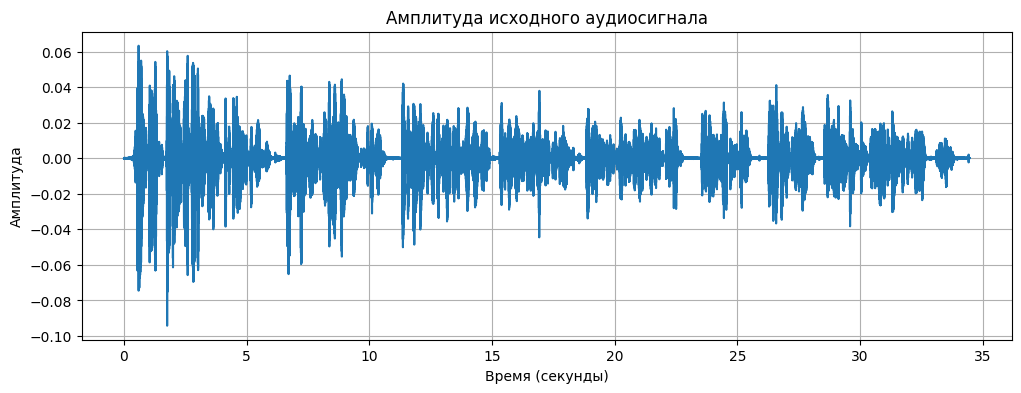

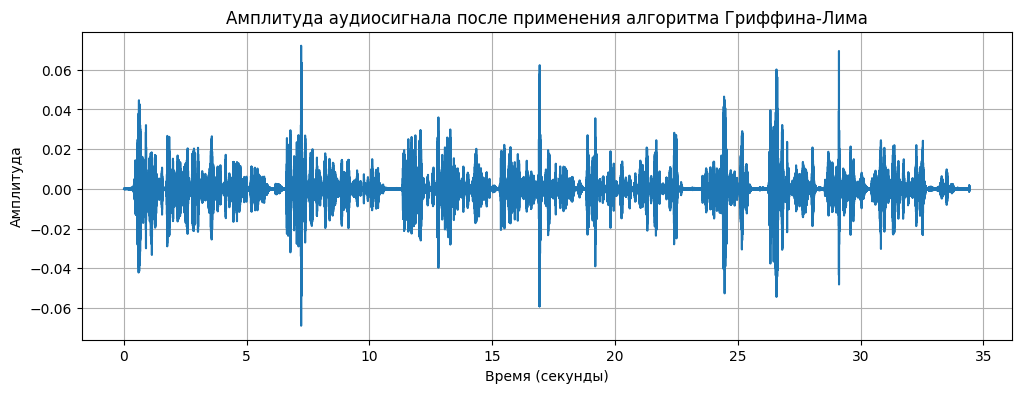

In [50]:
# Загрузка получившегося сигнала
X1, sr1 = librosa.load('reconstructed_audio.wav', sr=None)
# Обрезка тишины в начале и в конце
X1, _1 = librosa.effects.trim(X1)

print(len(X), len(X1))
print("частота дискреизации изначального сигнала:", sr)
print("частота дискреизации после Гриффина-Лима:", sr1)

# Вычисляем длительность исходного сигнала в секундах
duration = len(X) / sr
# Создаем временную ось
times = np.linspace(0, duration, len(X))
plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
plt.plot(times, X)           # Строим график амплитуды относительно времени
plt.title('Амплитуда исходного аудиосигнала')   # Добавляем заголовок
plt.xlabel('Время (секунды)')       # Подписываем оси
plt.ylabel('Амплитуда')
plt.grid(True)                      # Включаем сетку
plt.show()

# Вычисляем длительность получившегося сигнала в секундах
duration1 = len(X1) / sr1
# Создаем временную ось
times1 = np.linspace(0, duration1, len(X1))
plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
plt.plot(times1, X1)           # Строим график амплитуды относительно времени
plt.title('Амплитуда аудиосигнала после применения алгоритма Гриффина-Лима')   # Добавляем заголовок
plt.xlabel('Время (секунды)')       # Подписываем оси
plt.ylabel('Амплитуда')
plt.grid(True)                      # Включаем сетку
plt.show()

## Наблюдения:
На данном этапе было выполнено 100 итераций
Этого оказалось недостаточно: воспроизведение голоса стало тише, голос гундосит.

## Следующие действия

Применю метод локтя. Вместо 100 итераций будет неопределенное количество итераций. Чтобы необходимое количество итераций определялось методом локтя схожести амплитут каждые пять итераций. Завершить итерации тогда, когда значения перестанут сильно улучшаться.

In [51]:
# Читаем сигнал
X, sr = librosa.load('voice_16000.wav', sr=None)

# Предварительно обрезаем тишину
X, _ = librosa.effects.trim(X)

# Применяем pre-emphasis фильтр
y = np.append(X[0], X[1:] - 0.97 * X[:-1])

# Параметры преобразования
N = 2048       # Размер окна FFT
hop_length = N // 4  # Длина перекрытия

# Вычисляем начальную стфт
stft = librosa.stft(y, n_fft=N, hop_length=hop_length)

# Амплитуда спектрограммы
amplitudes = np.abs(stft)

# Случайная начальная фаза
phases = np.exp(2j * np.pi * np.random.rand(*amplitudes.shape))

# Начальные условия останова
tolerance = 1e-5           # Точность остановки
prev_error = float('inf')  # Значение предыдущей ошибки
iter_count = 0             # Текущее число итераций

while True:
    iter_count += 1
    
    # Воспроизводим сигнал
    reconstructed_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)
    
    # Пересчитываем стфт заново
    stft_reconstructed = librosa.stft(reconstructed_signal, n_fft=N, hop_length=hop_length)
    
    # Вычисляем новое значение фазы
    new_phases = np.angle(stft_reconstructed)
    
    # Обновляем фазы
    phases = np.exp(1j * new_phases)
    
    # Оцениваем ошибку (среднее абсолютное отклонение амплитуд)
    current_amplitudes = np.abs(stft_reconstructed)
    error = np.mean(np.abs(current_amplitudes - amplitudes))
    
    print(f"Iteration {iter_count}: Error={error:.6f}")
    
    if abs(prev_error - error) <= tolerance or iter_count > 1000:
        break
        
    prev_error = error

    # Проверка каждые 5 итераций
    if iter_count % 5 == 0:
        print(f"Current iteration {iter_count}, stopping condition check.")
        
print("Понадобилось итераций:", iter_count)

# Последний цикл восстановления сигнала
final_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)

# Убираем влияние pre-emphasis
final_signal_deemphasized = np.append(final_signal[0], final_signal[1:] + 0.97 * final_signal[:-1])

# Сохраняем восстановленный сигнал
sf.write('reconstructed_audio_dynamic_iter.wav', final_signal_deemphasized, sr)


Iteration 1: Error=0.014115
Iteration 2: Error=0.008505
Iteration 3: Error=0.007276
Iteration 4: Error=0.006582
Iteration 5: Error=0.006100
Current iteration 5, stopping condition check.
Iteration 6: Error=0.005734
Iteration 7: Error=0.005436
Iteration 8: Error=0.005182
Iteration 9: Error=0.004961
Iteration 10: Error=0.004764
Current iteration 10, stopping condition check.
Iteration 11: Error=0.004588
Iteration 12: Error=0.004429
Iteration 13: Error=0.004282
Iteration 14: Error=0.004147
Iteration 15: Error=0.004022
Current iteration 15, stopping condition check.
Iteration 16: Error=0.003904
Iteration 17: Error=0.003796
Iteration 18: Error=0.003694
Iteration 19: Error=0.003600
Iteration 20: Error=0.003513
Current iteration 20, stopping condition check.
Iteration 21: Error=0.003431
Iteration 22: Error=0.003355
Iteration 23: Error=0.003283
Iteration 24: Error=0.003214
Iteration 25: Error=0.003150
Current iteration 25, stopping condition check.
Iteration 26: Error=0.003089
Iteration 27: Er

551252 550912
частота дискреизации изначального сигнала: 16000
частота дискреизации после Гриффина-Лима: 16000


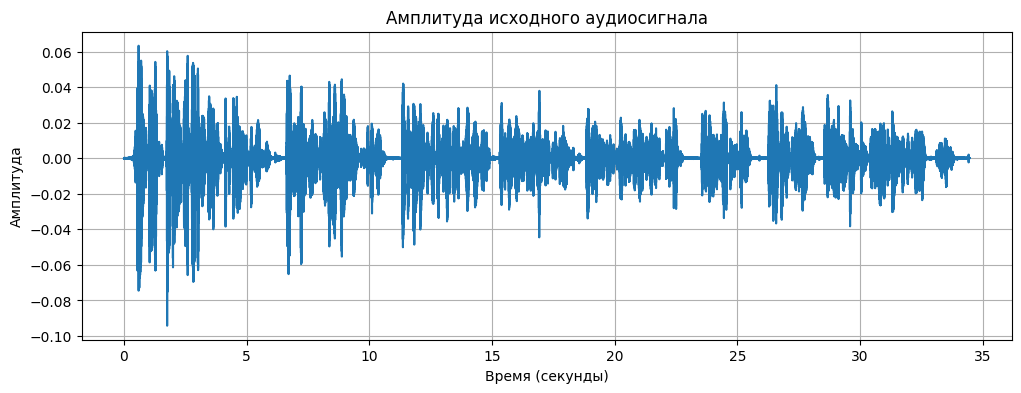

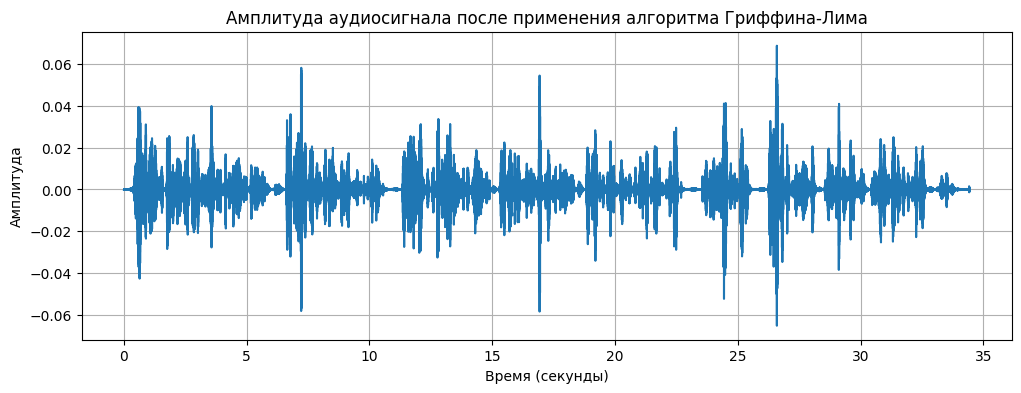

In [52]:
# Загрузка получившегося сигнала
X1, sr1 = librosa.load('reconstructed_audio_dynamic_iter.wav', sr=None)
# Обрезка тишины в начале и в конце
X1, _1 = librosa.effects.trim(X1)

print(len(X), len(X1))
print("частота дискреизации изначального сигнала:", sr)
print("частота дискреизации после Гриффина-Лима:", sr1)

# Вычисляем длительность исходного сигнала в секундах
duration = len(X) / sr
# Создаем временную ось
times = np.linspace(0, duration, len(X))
plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
plt.plot(times, X)           # Строим график амплитуды относительно времени
plt.title('Амплитуда исходного аудиосигнала')   # Добавляем заголовок
plt.xlabel('Время (секунды)')       # Подписываем оси
plt.ylabel('Амплитуда')
plt.grid(True)                      # Включаем сетку
plt.show()

# Вычисляем длительность получившегося сигнала в секундах
duration1 = len(X1) / sr1
# Создаем временную ось
times1 = np.linspace(0, duration1, len(X1))
plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
plt.plot(times1, X1)           # Строим график амплитуды относительно времени
plt.title('Амплитуда аудиосигнала после применения алгоритма Гриффина-Лима')   # Добавляем заголовок
plt.xlabel('Время (секунды)')       # Подписываем оси
plt.ylabel('Амплитуда')
plt.grid(True)                      # Включаем сетку
plt.show()

## Наблюдения
При прослушивании получившегося wav-файла разница практически не слышна: результат такой же, как в предыдущим эксперименте (тихий, гундосит).
Однако стало ясно, что не нужно выполнять 100 итераций, достаточно 81.

## Следующие действия

Не использовать преэмфазис

Выполнить 81 итерацию

In [53]:
# Читаем сигнал
X, sr = librosa.load('voice_16000.wav', sr=None)

# Предварительно обрезаем тишину
X, _ = librosa.effects.trim(X)

# Параметры преобразования
N = 2048      # Размер окна FFT
hop_length = N // 4  # Длина перекрытия

# Вычисляем stft сигнала
stft = librosa.stft(X, n_fft=N, hop_length=hop_length)

# Амплитуда спектрограммы
amplitudes = np.abs(stft)

# Генерация случайной начальной фазы
phases = np.exp(2j * np.pi * np.random.rand(*amplitudes.shape))

# Количество итераций
n_iterations = 81

for i in range(n_iterations):
    # Восстанавливаем временное представление
    reconstructed_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)
    
    # Обратно считаем stft
    stft_reconstructed = librosa.stft(reconstructed_signal, n_fft=N, hop_length=hop_length)
    
    # Берём фазовую составляющую нового спектра
    new_phases = np.angle(stft_reconstructed)
    
    # Обновляем фазы
    phases = np.exp(1j * new_phases)

# Последняя реконструкция временного сигнала
final_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)

sf.write('reconstructed_audio_81.wav', final_signal_deemphasized, sr)

551252 550912
частота дискреизации изначального сигнала: 16000
частота дискреизации после Гриффина-Лима: 16000


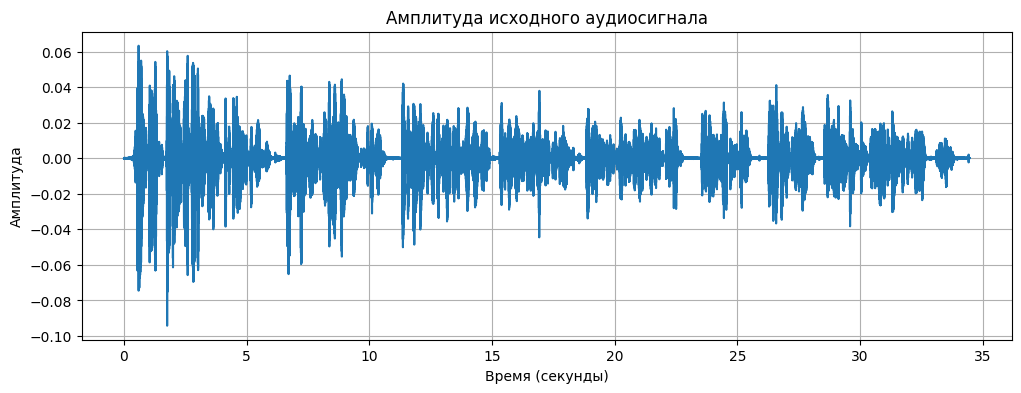

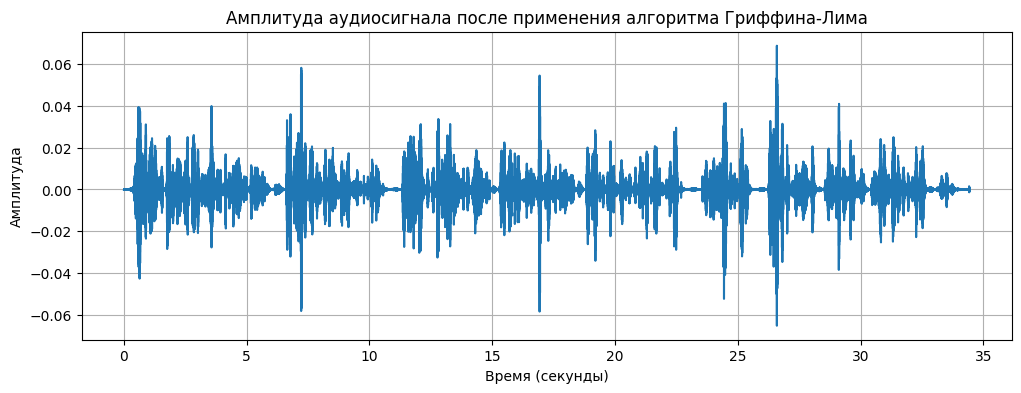

In [54]:
# Загрузка получившегося сигнала
X1, sr1 = librosa.load('reconstructed_audio_81.wav', sr=None)
# Обрезка тишины в начале и в конце
X1, _1 = librosa.effects.trim(X1)

print(len(X), len(X1))
print("частота дискреизации изначального сигнала:", sr)
print("частота дискреизации после Гриффина-Лима:", sr1)

# Вычисляем длительность исходного сигнала в секундах
duration = len(X) / sr
# Создаем временную ось
times = np.linspace(0, duration, len(X))
plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
plt.plot(times, X)           # Строим график амплитуды относительно времени
plt.title('Амплитуда исходного аудиосигнала')   # Добавляем заголовок
plt.xlabel('Время (секунды)')       # Подписываем оси
plt.ylabel('Амплитуда')
plt.grid(True)                      # Включаем сетку
plt.show()

# Вычисляем длительность получившегося сигнала в секундах
duration1 = len(X1) / sr1
# Создаем временную ось
times1 = np.linspace(0, duration1, len(X1))
plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
plt.plot(times1, X1)           # Строим график амплитуды относительно времени
plt.title('Амплитуда аудиосигнала после применения алгоритма Гриффина-Лима')   # Добавляем заголовок
plt.xlabel('Время (секунды)')       # Подписываем оси
plt.ylabel('Амплитуда')
plt.grid(True)                      # Включаем сетку
plt.show()

## Наблюдения:
При прослушивании файла нет отличий от версии с использованием преэмфазиса.
Поэтому можно не делать лишние фильтры.

# Проверка с частотой 8000 Hz

Метод локтя

In [55]:
# Загружаем файл, сохраняя оригинальную частоту дискретизации
X, sr = librosa.load('voice_8000.wav', sr=None)

print("Частота:", sr)

Частота: 8000


In [56]:
# Предварительно обрезаем тишину
X, _ = librosa.effects.trim(X)

# Применяем pre-emphasis фильтр
y = np.append(X[0], X[1:] - 0.97 * X[:-1])

# Параметры преобразования
N = 2048       # Размер окна FFT
hop_length = N // 4  # Длина перекрытия

# Вычисляем начальную стфт
stft = librosa.stft(y, n_fft=N, hop_length=hop_length)

# Амплитуда спектрограммы
amplitudes = np.abs(stft)

# Случайная начальная фаза
phases = np.exp(2j * np.pi * np.random.rand(*amplitudes.shape))

# Начальные условия останова
tolerance = 1e-5           # Точность остановки
prev_error = float('inf')  # Значение предыдущей ошибки
iter_count = 0             # Текущее число итераций

while True:
    iter_count += 1
    
    # Воспроизводим сигнал
    reconstructed_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)
    
    # Пересчитываем стфт заново
    stft_reconstructed = librosa.stft(reconstructed_signal, n_fft=N, hop_length=hop_length)
    
    # Вычисляем новое значение фазы
    new_phases = np.angle(stft_reconstructed)
    
    # Обновляем фазы
    phases = np.exp(1j * new_phases)
    
    # Оцениваем ошибку (среднее абсолютное отклонение амплитуд)
    current_amplitudes = np.abs(stft_reconstructed)
    error = np.mean(np.abs(current_amplitudes - amplitudes))
    
    print(f"Iteration {iter_count}: Error={error:.6f}")
    
    if abs(prev_error - error) <= tolerance or iter_count > 1000:
        break
        
    prev_error = error

    # Проверка каждые 5 итераций
    if iter_count % 5 == 0:
        print(f"Current iteration {iter_count}, stopping condition check.")
        
print("Понадобилось итераций:", iter_count)

# Последний цикл восстановления сигнала
final_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)

# Убираем влияние pre-emphasis
final_signal_deemphasized = np.append(final_signal[0], final_signal[1:] + 0.97 * final_signal[:-1])

# Сохраняем восстановленный сигнал
sf.write('reconstructed_audio_dynamic_iter_8000.wav', final_signal_deemphasized, sr)

Iteration 1: Error=0.043840
Iteration 2: Error=0.026677
Iteration 3: Error=0.022998
Iteration 4: Error=0.020926
Iteration 5: Error=0.019481
Current iteration 5, stopping condition check.
Iteration 6: Error=0.018359
Iteration 7: Error=0.017437
Iteration 8: Error=0.016650
Iteration 9: Error=0.015967
Iteration 10: Error=0.015362
Current iteration 10, stopping condition check.
Iteration 11: Error=0.014817
Iteration 12: Error=0.014326
Iteration 13: Error=0.013881
Iteration 14: Error=0.013473
Iteration 15: Error=0.013091
Current iteration 15, stopping condition check.
Iteration 16: Error=0.012734
Iteration 17: Error=0.012401
Iteration 18: Error=0.012089
Iteration 19: Error=0.011800
Iteration 20: Error=0.011528
Current iteration 20, stopping condition check.
Iteration 21: Error=0.011272
Iteration 22: Error=0.011029
Iteration 23: Error=0.010798
Iteration 24: Error=0.010579
Iteration 25: Error=0.010373
Current iteration 25, stopping condition check.
Iteration 26: Error=0.010178
Iteration 27: Er

## Наблюдения:

чем меньше частота, тем больше итераций требуется

## Следующий шаг:

Выполнить с частотой 22050

In [57]:
# Загружаем файл, сохраняя оригинальную частоту дискретизации
X, sr = librosa.load('voice_8000.wav')

print("Частота:", sr)

Частота: 22050


In [58]:
# Предварительно обрезаем тишину
X, _ = librosa.effects.trim(X)

# Применяем pre-emphasis фильтр
y = np.append(X[0], X[1:] - 0.97 * X[:-1])

# Параметры преобразования
N = 2048       # Размер окна FFT
hop_length = N // 4  # Длина перекрытия

# Вычисляем начальную стфт
stft = librosa.stft(y, n_fft=N, hop_length=hop_length)

# Амплитуда спектрограммы
amplitudes = np.abs(stft)

# Случайная начальная фаза
phases = np.exp(2j * np.pi * np.random.rand(*amplitudes.shape))

# Начальные условия останова
tolerance = 1e-5           # Точность остановки
prev_error = float('inf')  # Значение предыдущей ошибки
iter_count = 0             # Текущее число итераций

while True:
    iter_count += 1
    
    # Воспроизводим сигнал
    reconstructed_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)
    
    # Пересчитываем стфт заново
    stft_reconstructed = librosa.stft(reconstructed_signal, n_fft=N, hop_length=hop_length)
    
    # Вычисляем новое значение фазы
    new_phases = np.angle(stft_reconstructed)
    
    # Обновляем фазы
    phases = np.exp(1j * new_phases)
    
    # Оцениваем ошибку (среднее абсолютное отклонение амплитуд)
    current_amplitudes = np.abs(stft_reconstructed)
    error = np.mean(np.abs(current_amplitudes - amplitudes))
    
    print(f"Iteration {iter_count}: Error={error:.6f}")
    
    if abs(prev_error - error) <= tolerance or iter_count > 1000:
        break
        
    prev_error = error

    # Проверка каждые 5 итераций
    if iter_count % 5 == 0:
        print(f"Current iteration {iter_count}, stopping condition check.")
        
print("Понадобилось итераций:", iter_count)

# Последний цикл восстановления сигнала
final_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)

# Убираем влияние pre-emphasis
final_signal_deemphasized = np.append(final_signal[0], final_signal[1:] + 0.97 * final_signal[:-1])

# Сохраняем восстановленный сигнал
sf.write('reconstructed_audio_dynamic_iter_8000.wav', final_signal_deemphasized, sr)

Iteration 1: Error=0.008825
Iteration 2: Error=0.005401
Iteration 3: Error=0.004623
Iteration 4: Error=0.004180
Iteration 5: Error=0.003873
Current iteration 5, stopping condition check.
Iteration 6: Error=0.003636
Iteration 7: Error=0.003444
Iteration 8: Error=0.003281
Iteration 9: Error=0.003140
Iteration 10: Error=0.003017
Current iteration 10, stopping condition check.
Iteration 11: Error=0.002905
Iteration 12: Error=0.002803
Iteration 13: Error=0.002708
Iteration 14: Error=0.002621
Iteration 15: Error=0.002539
Current iteration 15, stopping condition check.
Iteration 16: Error=0.002464
Iteration 17: Error=0.002393
Iteration 18: Error=0.002327
Iteration 19: Error=0.002265
Iteration 20: Error=0.002207
Current iteration 20, stopping condition check.
Iteration 21: Error=0.002151
Iteration 22: Error=0.002099
Iteration 23: Error=0.002051
Iteration 24: Error=0.002005
Iteration 25: Error=0.001962
Current iteration 25, stopping condition check.
Iteration 26: Error=0.001922
Iteration 27: Er

## Наблюдения:
    
    При том же файле с частотой 22050 понадобилось почти в 3 раза меньше итераций, чем с частотй 8000
    
## Следующий шаг:

    Проверить тот же файл с частотой 16000

In [59]:
# Загружаем файл, сохраняя оригинальную частоту дискретизации
X, sr = librosa.load('voice_8000.wav', sr=16000)

print("Частота:", sr)

Частота: 16000


In [60]:
# Предварительно обрезаем тишину
X, _ = librosa.effects.trim(X)

# Применяем pre-emphasis фильтр
y = np.append(X[0], X[1:] - 0.97 * X[:-1])

# Параметры преобразования
N = 2048       # Размер окна FFT
hop_length = N // 4  # Длина перекрытия

# Вычисляем начальную стфт
stft = librosa.stft(y, n_fft=N, hop_length=hop_length)

# Амплитуда спектрограммы
amplitudes = np.abs(stft)

# Случайная начальная фаза
phases = np.exp(2j * np.pi * np.random.rand(*amplitudes.shape))

# Начальные условия останова
tolerance = 1e-5           # Точность остановки
prev_error = float('inf')  # Значение предыдущей ошибки
iter_count = 0             # Текущее число итераций

while True:
    iter_count += 1
    
    # Воспроизводим сигнал
    reconstructed_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)
    
    # Пересчитываем стфт заново
    stft_reconstructed = librosa.stft(reconstructed_signal, n_fft=N, hop_length=hop_length)
    
    # Вычисляем новое значение фазы
    new_phases = np.angle(stft_reconstructed)
    
    # Обновляем фазы
    phases = np.exp(1j * new_phases)
    
    # Оцениваем ошибку (среднее абсолютное отклонение амплитуд)
    current_amplitudes = np.abs(stft_reconstructed)
    error = np.mean(np.abs(current_amplitudes - amplitudes))
    
    print(f"Iteration {iter_count}: Error={error:.6f}")
    
    if abs(prev_error - error) <= tolerance or iter_count > 1000:
        break
        
    prev_error = error

    # Проверка каждые 5 итераций
    if iter_count % 5 == 0:
        print(f"Current iteration {iter_count}, stopping condition check.")
        
print("Понадобилось итераций:", iter_count)

# Последний цикл восстановления сигнала
final_signal = librosa.istft(amplitudes * phases, hop_length=hop_length)

# Убираем влияние pre-emphasis
final_signal_deemphasized = np.append(final_signal[0], final_signal[1:] + 0.97 * final_signal[:-1])

# Сохраняем восстановленный сигнал
sf.write('reconstructed_audio_dynamic_iter_16000.wav', final_signal_deemphasized, sr)

Iteration 1: Error=0.014812
Iteration 2: Error=0.008907
Iteration 3: Error=0.007605
Iteration 4: Error=0.006876
Iteration 5: Error=0.006378
Current iteration 5, stopping condition check.
Iteration 6: Error=0.005995
Iteration 7: Error=0.005677
Iteration 8: Error=0.005403
Iteration 9: Error=0.005168
Iteration 10: Error=0.004960
Current iteration 10, stopping condition check.
Iteration 11: Error=0.004772
Iteration 12: Error=0.004600
Iteration 13: Error=0.004444
Iteration 14: Error=0.004302
Iteration 15: Error=0.004171
Current iteration 15, stopping condition check.
Iteration 16: Error=0.004049
Iteration 17: Error=0.003935
Iteration 18: Error=0.003830
Iteration 19: Error=0.003732
Iteration 20: Error=0.003641
Current iteration 20, stopping condition check.
Iteration 21: Error=0.003555
Iteration 22: Error=0.003475
Iteration 23: Error=0.003399
Iteration 24: Error=0.003326
Iteration 25: Error=0.003257
Current iteration 25, stopping condition check.
Iteration 26: Error=0.003190
Iteration 27: Er

In [ ]:
## Наблюдения:
С частотой 16000 понадобилось в ~2 раза меньше итераций, чем с частотой 8000
С частотой 22050 понадобилось в ~3 раза меньше итераций, чем с частотой 8000

## Вывод:

1. Чем выше частота, тем меньше итераций алгоритма Гриффина-Лима требуется
2. Полагаю, что качество восстановления можно добиться фильтрами предобработки и постобработки аудиосигнала